# CIS433 Project 3 — English → Spanish Transformer Translator
**Simon Business School | University of Rochester**

Architecture: Transformer (Encoder-Decoder) from `rui.torch.transformer`  
Config: `d_emb=128, n_layers=2, n_heads=8, d_ff=512`

## 1. Mount Drive & Imports

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os, sys, string, random, pickle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader


BASE     = '/content/drive/MyDrive/SIMON BUSINESS SCHOOL/CIS433 - AI & Deep Learning'
PROJECT  = f'{BASE}/project 3 deep learning'
sys.path.append(PROJECT)   # rui/ lives here now

DATA_PATH = f'{PROJECT}/spa.txt'   # note: your file is named spa.txt.txt
MODEL_DIR = PROJECT                     # save weights in the same folder

In [3]:
from rui.utils import TextVectorizer
from rui.torch.utils import train, plotEpoch
from rui.torch.transformer import Transformer

gpu_id = 0
device = torch.device(f'cuda:{gpu_id}' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Importingfrom local file "rui.utils.py"
Transformer imported from local file "rui.torch.transformer.py"
Using device: cuda:0


In [4]:
import inspect, rui.utils, rui.torch.transformer
print(inspect.getfile(rui.utils))

/content/drive/MyDrive/SIMON BUSINESS SCHOOL/CIS433 - AI & Deep Learning/project 3 deep learning/rui/utils.py


In [5]:
with open('/content/drive/MyDrive/SIMON BUSINESS SCHOOL/CIS433 - AI & Deep Learning/project 3 deep learning/rui/utils.py') as f:
    print(f.read()[:2000])

import numpy as np
from collections import Counter
import re
import pickle
 
#%%
 
class TextVectorizer:
    def __init__(self, max_tokens=20000, output_mode="int", output_sequence_length=None, ngrams=None, standardize=None):
        self.max_tokens = max_tokens
        self.output_mode = output_mode
        self.output_sequence_length = output_sequence_length
        self.ngrams = ngrams
        self.standardize = standardize
        self.vocab = None
        self.word_to_idx = None
        self.idx_to_word = None
        self.idf_weights = None
 
    def _tokenize(self, text):
        if self.standardize:
            text = self.standardize(text)
        else:
            text = text.lower()
            text = re.sub(r'', ' ', text)
            text = re.sub(r'[^\w\s]', ' ', text)
        tokens = text.split()
        if self.ngrams and self.ngrams >= 2:
            ngram_tokens = []
            for n in range(1, self.ngrams + 1):
                for i in range( len(tokens) - n + 1 )

In [6]:
with open('/content/drive/MyDrive/SIMON BUSINESS SCHOOL/CIS433 - AI & Deep Learning/project 3 deep learning/rui/torch/utils.py') as f:
    print(f.read()[:2000])

#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
A collection of utility functions for CIS433
@author: huaxia
"""
 
import os
import time
import numpy as np
import copy
import matplotlib.pyplot as plt
 
import torch
import torch.nn as nn
 
#%%
 
class ModelCheckpoint:
    def __init__(self, filepath, monitor="val_loss", save_best_only=True, save_optimizer_state=False):
        self.filepath = filepath
        self.monitor = monitor
        self.save_best_only = save_best_only
        self.save_optimizer_state = save_optimizer_state
        os.makedirs(os.path.dirname(filepath), exist_ok=True)
 
    def on_best(self, model, optimizer):
        if self.save_optimizer_state:
            torch.save( {"model_state_dict": model.state_dict(), "optimizer_state_dict": optimizer.state_dict()}, self.filepath)
        else:
            torch.save(model.state_dict(), self.filepath)
 
 
def plotEpoch(history, metric="average_loss"):
    epochs = range(len(history["average_train_loss"]))
    if met

## 2. Load & Preprocess Data

In [7]:
import os
print(os.listdir(PROJECT))

['train_translator.ipynb', 'Project 3.docx', 'rui_torch_transformer.py', 'rui.torch.transformer.py', 'inference.py', 'app (1).py', 'rui', 'spa-eng.zip', 'spa-eng', 'translator_vectorizers.pkl', 'translator_weights.pt', 'spa.txt']


In [8]:
with open(DATA_PATH, 'rb') as f:
    raw = f.read(500)
print(raw)

b'Go.\tVe.\r\nGo.\tVete.\r\nGo.\tVaya.\r\nGo.\tV\xc3\xa1yase.\r\nHi.\tHola.\r\nRun!\t\xc2\xa1Corre!\r\nRun.\tCorred.\r\nWho?\t\xc2\xbfQui\xc3\xa9n?\r\nFire!\t\xc2\xa1Fuego!\r\nFire!\t\xc2\xa1Incendio!\r\nFire!\t\xc2\xa1Disparad!\r\nHelp!\t\xc2\xa1Ayuda!\r\nHelp!\t\xc2\xa1Socorro! \xc2\xa1Auxilio!\r\nHelp!\t\xc2\xa1Auxilio!\r\nJump!\t\xc2\xa1Salta!\r\nJump.\tSalte.\r\nStop!\t\xc2\xa1Parad!\r\nStop!\t\xc2\xa1Para!\r\nStop!\t\xc2\xa1Pare!\r\nWait!\t\xc2\xa1Espera!\r\nWait.\tEsperen.\r\nGo on.\tContin\xc3\xbaa.\r\nGo on.\tContin\xc3\xbae.\r\nHello!\tHola.\r\nI ran.\tCorr\xc3\xad.\r\nI ran.\tCorr\xc3\xada.\r\nI try.\tLo intento.\r\nI won!\t\xc2\xa1He ganado!\r\nOh no!\t\xc2\xa1Oh, no!\r\nRelax.\tTom\xc3\xa1telo con soda.\r\nS'


In [ ]:
# downloading the text file

'''import urllib.request, zipfile

urllib.request.urlretrieve(
    'http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip',
    f'{PROJECT}/spa-eng.zip'
)

with zipfile.ZipFile(f'{PROJECT}/spa-eng.zip', 'r') as z:
    z.extractall(f'{PROJECT}/')

# Update DATA_PATH to the freshly extracted file
DATA_PATH = f'{PROJECT}/spa-eng/spa.txt'

# Verify
with open(DATA_PATH) as f:
    lines = f.read().split('\n')[:-1]
print(f'Total sentence pairs: {len(lines)}')
print(f'Sample: {lines[100]}')

Total sentence pairs: 118964
Sample: Go away!	¡Salga de aquí!


In [10]:
with open(DATA_PATH) as f:
    lines = f.read().split('\n')[:-1]
print(f'Total sentence pairs: {len(lines)}')
print(f'Sample: {lines[100]}')

Total sentence pairs: 118963
Sample: Go away!	¡Salga de aquí!


In [11]:
# Punctuation stripping (keep [ and ] for [start]/[end] tokens)
strip_chars = string.punctuation + '¿'
strip_chars = strip_chars.replace('[', '').replace(']', '')

def custom_standardization(input_string):
    input_string = input_string.lower()
    for char in strip_chars:
        input_string = input_string.replace(char, '')
    return input_string

vocab_size = 15000
seq_len    = 50
batch_size = 64

# Add [start] and [end] tokens to Spanish targets
text_pairs = []
for line in lines:
    english, spanish = line.split('\t')
    spanish = '[start] ' + spanish + ' [end]'
    text_pairs.append((english, spanish))

random.seed(42)
random.shuffle(text_pairs)
num_val   = int(0.15 * len(text_pairs))
num_train = len(text_pairs) - 2 * num_val
train_pairs = text_pairs[:num_train]
val_pairs   = text_pairs[num_train:num_train + num_val]
test_pairs  = text_pairs[num_train + num_val:]
print(f'Train: {len(train_pairs)} | Val: {len(val_pairs)} | Test: {len(test_pairs)}')

Train: 83275 | Val: 17844 | Test: 17844


## 3. Build Vectorizers & Save Them

In [12]:
# Source (English) vectorizer
source_vectorizer = TextVectorizer(
    max_tokens=vocab_size,
    output_sequence_length=seq_len,
    standardize=custom_standardization
)
source_vectorizer.adapt([pair[0] for pair in train_pairs])

# Target (Spanish) vectorizer — seq_len+1 so we can shift by 1 for teacher forcing
target_vectorizer = TextVectorizer(
    max_tokens=vocab_size,
    output_sequence_length=seq_len + 1,
    standardize=custom_standardization
)
target_vectorizer.adapt([pair[1] for pair in train_pairs])

# Vocabulary lookup: index -> word (used at inference time)
spa_vocab        = target_vectorizer.get_vocabulary()
spa_index_lookup = dict(zip(range(len(spa_vocab)), spa_vocab))

start_idx = target_vectorizer.word_to_idx.get('[start]')
end_idx   = target_vectorizer.word_to_idx.get('[end]')
print(f'Vocab size: {len(spa_vocab)}')
print(f'[start] idx: {start_idx} | [end] idx: {end_idx}')

# ── Save vectorizers + lookup so inference works without retraining ──
vectorizer_data = {
    'source_vectorizer': source_vectorizer,
    'target_vectorizer': target_vectorizer,
    'spa_index_lookup':  spa_index_lookup,
    'start_idx':         start_idx,
    'end_idx':           end_idx,
    'seq_len':           seq_len,
    'vocab_size':        vocab_size,
}
with open(f'{MODEL_DIR}/translator_vectorizers.pkl', 'wb') as f:
    pickle.dump(vectorizer_data, f)
print('Vectorizers saved.')

Adapting TextVectorizer...
Vocabulary size: 12090
Adapting TextVectorizer...
Vocabulary size: 15000
Vocab size: 15000
[start] idx: 2 | [end] idx: 3
Vectorizers saved.


## 4. Dataset & DataLoaders

In [13]:
class TranslationDataset(Dataset):
    def __init__(self, pairs, source_vectorizer, target_vectorizer):
        self.pairs = pairs
        self.sv = source_vectorizer
        self.tv = target_vectorizer

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, i):
        eng, spa = self.pairs[i]
        eng_vec = self.sv(eng).squeeze(0)          # (seq_len,)
        spa_vec = self.tv(spa).squeeze(0)          # (seq_len+1,)
        return eng_vec, spa_vec[:-1], spa_vec[1:]  # src, tgt_in, tgt_out

train_dataset = TranslationDataset(train_pairs, source_vectorizer, target_vectorizer)
val_dataset   = TranslationDataset(val_pairs,   source_vectorizer, target_vectorizer)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=0)

# Sanity check shapes
src, tgt_in, tgt_out = next(iter(train_loader))
print(f'src shape:     {src.shape}')     # (64, 20)
print(f'tgt_in shape:  {tgt_in.shape}')  # (64, 20)
print(f'tgt_out shape: {tgt_out.shape}') # (64, 20)

src shape:     torch.Size([64, 50])
tgt_in shape:  torch.Size([64, 50])
tgt_out shape: torch.Size([64, 50])


## 5. Loss & Accuracy Functions

In [14]:
'''def masked_loss(pred, label):
    """
    pred:  (batch, seq_len, vocab_size)
    label: (batch, seq_len)
    Ignores padding positions (token index == 0).
    """
    loss_fn = nn.CrossEntropyLoss(reduction='none')
    pred  = pred.view(-1, pred.size(-1))  # (batch*seq_len, vocab_size)
    label = label.view(-1)                # (batch*seq_len,)
    loss  = loss_fn(pred, label)
    mask  = (label != 0).float()
    return (loss * mask).sum() / mask.sum()'''

def masked_loss(pred, label):
    loss_fn = nn.CrossEntropyLoss(reduction='none', label_smoothing=0.1)
    pred  = pred.view(-1, pred.size(-1))
    label = label.view(-1)
    loss  = loss_fn(pred, label)
    mask  = (label != 0).float()
    return (loss * mask).sum() / mask.sum()


def masked_accuracy(pred, label):
    pred  = torch.argmax(pred, dim=2)     # (batch, seq_len)
    mask  = (label != 0)
    match = ((label == pred) & mask).float()
    return match.sum() / mask.float().sum()

## 6. Build the Transformer Model

Using `rui.torch.transformer.Transformer` with the required config:
- `d_emb=128, n_layers=2, n_heads=8, d_ff=512`

In [15]:
# rui's Transformer.forward() expects x = (src, tgt) — matches our DataLoader perfectly
model = Transformer(
    n_layers      = 2,
    d_emb         = 128,
    n_heads       = 8,
    d_ff          = 512,
    src_vocab_size= vocab_size,
    tgt_vocab_size= vocab_size,
    seq_len       = seq_len + 1,  # +1 to accommodate teacher-forced target input
    dropout       = 0.1,
    prenorm       = True,
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')

Trainable parameters: 6,697,880


## 7. Train

Start training on device cuda:0.

 Epoch  |  Batch  |  Train Loss  |  Val Loss  | Train Acc |  Val Acc  |  Elapsed 
--------------------------------------------------------------------------------
   1    |   100   |   8.604620   |     -      |   14.29   |     -     |   0.02   
   1    |   200   |   7.464338   |     -      |   14.07   |     -     |   0.02   
   1    |   300   |   6.942125   |     -      |   15.92   |     -     |   0.02   
   1    |   400   |   6.469126   |     -      |   18.72   |     -     |   0.02   
   1    |   500   |   6.122956   |     -      |   23.18   |     -     |   0.02   
   1    |   600   |   6.138370   |     -      |   21.52   |     -     |   0.02   
   1    |   700   |   5.962268   |     -      |   25.55   |     -     |   0.02   
   1    |   800   |   5.824757   |     -      |   27.45   |     -     |   0.02   
   1    |   900   |   5.609989   |     -      |   25.98   |     -     |   0.02   
   1    |  1000   |   5.570532   |     -      |   31.58   |     -

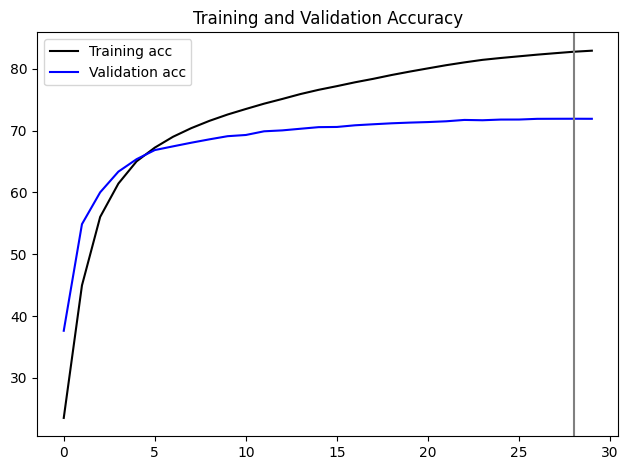

In [16]:
'''optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda step: 1.0)  # static LR

history = train(
    model,
    train_loader,
    val_loader,
    optimizer,
    loss_fn     = masked_loss,
    accuracy_fn = masked_accuracy,
    scheduler   = scheduler,
    device      = device,
    n_epochs    = 30,
    n_batch_per_report = 100,
)

plotEpoch(history, metric='accuracy')'''

import math

n_epochs  = 30
n_batches = len(train_loader)
warmup_steps = n_batches * 3

def lr_lambda(step):
    if step == 0:
        return 1e-8
    if step < warmup_steps:
        return step / warmup_steps
    progress = (step - warmup_steps) / (n_epochs * n_batches - warmup_steps)
    return 0.5 * (1 + math.cos(math.pi * progress))

optimizer = optim.Adam(model.parameters(), lr=1e-3, betas=(0.9, 0.98), eps=1e-9)
scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

history = train(
    model,
    train_loader,
    val_loader,
    optimizer,
    loss_fn     = masked_loss,
    accuracy_fn = masked_accuracy,
    scheduler   = scheduler,
    device      = device,
    n_epochs    = n_epochs,
    n_batch_per_report = 100,
)

plotEpoch(history, metric='accuracy')

## 8. Save Model Weights

In [17]:
torch.save(model.state_dict(), f'{MODEL_DIR}/translator_weights.pt')
print('Model weights saved.')

Model weights saved.


## 9. Inference — Greedy Decoding

At inference time we **cannot** use teacher forcing (we don't have the target).  
Instead we decode autoregressively: feed `[start]`, get token 1, feed token 1, get token 2, … until `[end]` or max length.

In [18]:
import torch.nn.functional as F

def translate(sentence, model, source_vectorizer, spa_index_lookup,
              start_idx, end_idx, seq_len, device, max_len=20):
    model.eval()
    with torch.no_grad():
        # Encode source
        src = source_vectorizer(sentence)          # (1, seq_len)
        src = torch.tensor(src, dtype=torch.long).to(device)

        # Start decoding with [start] token
        decoded = [start_idx]

        for _ in range(max_len):
            # Pad / truncate target so far to seq_len
            tgt_seq = decoded[:seq_len]
            tgt_seq_padded = tgt_seq + [0] * (seq_len - len(tgt_seq))
            tgt = torch.tensor([tgt_seq_padded], dtype=torch.long).to(device)  # (1, seq_len)

            logits = model((src, tgt))   # (1, seq_len, vocab_size)
            # Predict the next token at the last non-padded position
            next_token_logits = logits[0, len(decoded) - 1, :]  # (vocab_size,)
            next_token = torch.argmax(next_token_logits).item()

            if next_token == end_idx or next_token == 0:
                break
            decoded.append(next_token)

        # Convert indices to words, skip [start]
        words = [spa_index_lookup.get(idx, '') for idx in decoded[1:]]
        return ' '.join(w for w in words if w)

# Quick test
test_sentences = [
    'Hello, how are you?',
    'I love to learn new things.',
    'What time is it?',
    'The weather is beautiful today.',
]
for s in test_sentences:
    print(f'EN: {s}')
    print(f'ES: {translate(s, model, source_vectorizer, spa_index_lookup, start_idx, end_idx, seq_len, device)}')
    print()

EN: Hello, how are you?
ES: hola cómo eres

EN: I love to learn new things.
ES: me encanta aprender cosas nuevas

EN: What time is it?
ES: a qué hora es

EN: The weather is beautiful today.
ES: hoy hace buen tiempo



## 10. Verify Full Save/Load Pipeline
This simulates exactly what the grader will do — load from disk on a fresh machine.

In [19]:
import pickle
from rui.torch.transformer import Transformer

# ── Load vectorizers ─────────────────────────────────────────────────
with open(f'{MODEL_DIR}/translator_vectorizers.pkl', 'rb') as f:
    vdata = pickle.load(f)

src_vec_loaded  = vdata['source_vectorizer']
idx_lookup      = vdata['spa_index_lookup']
start_idx_      = vdata['start_idx']
end_idx_        = vdata['end_idx']
seq_len_        = vdata['seq_len']
vocab_size_     = vdata['vocab_size']

# ── Rebuild model architecture & load weights ────────────────────────
loaded_model = Transformer(
    n_layers      = 2,
    d_emb         = 128,
    n_heads       = 8,
    d_ff          = 512,
    src_vocab_size= vocab_size_,
    tgt_vocab_size= vocab_size_,
    seq_len       = seq_len_ + 1,
    dropout       = 0.1,
    prenorm       = True,
).to(device)
loaded_model.load_state_dict(torch.load(f'{MODEL_DIR}/translator_weights.pt', map_location=device))

# ── Test ─────────────────────────────────────────────────────────────
sentence = 'Good morning, how are you?'
result = translate(sentence, loaded_model, src_vec_loaded, idx_lookup,
                   start_idx_, end_idx_, seq_len_, device)
print(f'EN: {sentence}')
print(f'ES: {result}')
print('\nFull pipeline verified!')

EN: Good morning, how are you?
ES: bueno por qué es usted

Full pipeline verified!


In [20]:
import os
for f in ['translator_weights.pt', 'translator_vectorizers.pkl']:
    size = os.path.getsize(f'{MODEL_DIR}/{f}')
    print(f'{f}: {size/1024/1024:.1f} MB')

translator_weights.pt: 25.6 MB
translator_vectorizers.pkl: 0.8 MB
